# 09 · Localising the risk behaviors with open-vocabulary + segmentation

**Why this notebook.** Our 3 competition clips define **3 risk cases**:

| Clip | Risk case (our label) |
|---|---|
| tekno-01 | **SMOKING** (`cigarette`) |
| tekno-02 | **PHONE CALL** (`mobile phone`) |
| tekno-03 | **RECKLESS / SWERVING** (from the trajectory, not a cabin object) |

The trained model could not localise *smoking*. Here we use two foundation models
— **off the live path** — purely to **localise and auto-label** the behavior region:

- **YOLO-World** — open-vocabulary detection: prompt `cigarette` / `mobile phone` /
  `person` and it returns those concepts (no training).
- **SAM 2** — turns the driver detection into a **pixel mask**.

Goal: map **our labels** onto the exact pixels — input for fine-tuning the fast model.

In [1]:
%matplotlib inline
import cv2, numpy as np, glob
import matplotlib.pyplot as plt
from ultralytics import YOLO, YOLOWorld, SAM
DEV = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
veh = YOLO("../backend/yolov8x.pt")
world = YOLOWorld("../backend/yolov8x-worldv2.pt")
sam = SAM("../backend/sam2_b.pt")
TAXO = {"cigarette": ("SMOKING", (255,60,60)), "mobile phone": ("PHONE CALL", (60,160,255))}
world.set_classes(list(TAXO) + ["person"])
print("loaded YOLO-World (concepts) + SAM2 (masks); labels:", [v[0] for v in TAXO.values()]+["DRIVER"])

C:\Users\USUARIO\Downloads\Nueva carpeta (35)\TeknoFest\backend\.venv\Lib\site-packages\clip\clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


loaded YOLO-World (concepts) + SAM2 (masks); labels: ['SMOKING', 'PHONE CALL', 'DRIVER']


### Scan every frame of the clip and keep the one where the concept is actually detected

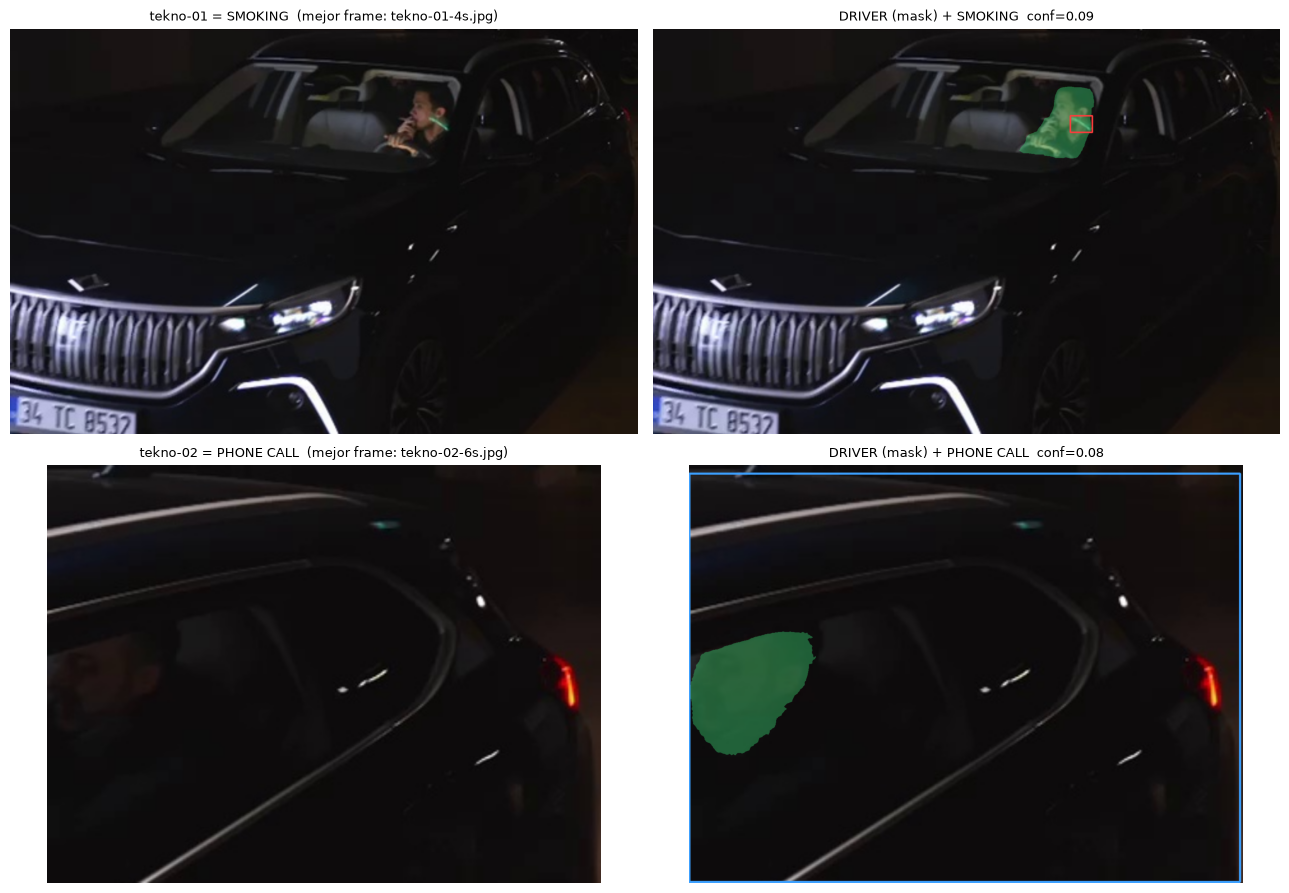

In [2]:
def scan(clip, expected):
    best = None
    for f in sorted(glob.glob('../tmp/frames/' + clip + '-*.jpg')):
        img = cv2.imread(f)
        r = veh.predict(img, imgsz=512, conf=0.25, classes=[2,3,5,7], device=DEV, verbose=False)[0]
        if not len(r.boxes):
            continue
        b = max(r.boxes, key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
        x1,y1,x2,y2 = [int(v) for v in b.xyxy[0].tolist()]
        crop = cv2.resize(img[y1:y2, x1:x2], None, fx=4, fy=4)
        w = world.predict(crop, imgsz=640, conf=0.02, device=DEV, verbose=False)[0]
        dets = [(world.names[int(d.cls)], float(d.conf), [int(v) for v in d.xyxy[0].tolist()]) for d in w.boxes]
        score = max([c for n,c,_ in dets if n==expected], default=0.0)
        if best is None or score > best[0]:
            best = (score, crop, dets, os.path.basename(f))
    return best

def render(clip, expected):
    score, crop, dets, fname = scan(clip, expected)
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB); overlay = rgb.copy()
    persons = sorted([d for d in dets if d[0]=="person"], key=lambda x:-x[1])
    if persons:
        s = sam(crop, bboxes=[persons[0][2]], device=DEV, verbose=False)[0]
        if getattr(s, "masks", None) is not None:
            mk = s.masks.data.cpu().numpy()[0].astype(bool)
            overlay[mk] = (0.6*overlay[mk] + 0.4*np.array([60,220,120])).astype(np.uint8)
    label, col = TAXO[expected]
    note = "DRIVER (mask) + " + label
    conc = sorted([d for d in dets if d[0]==expected], key=lambda x:-x[1])
    if conc:
        bx = conc[0][2]; cv2.rectangle(overlay,(bx[0],bx[1]),(bx[2],bx[3]),col,3)
        note += "  conf=%.2f" % conc[0][1]
    return rgb, overlay, note, fname

import os
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (clip, expected, title) in zip(axes, [("tekno-01","cigarette","tekno-01 = SMOKING"),
                                              ("tekno-02","mobile phone","tekno-02 = PHONE CALL")]):
    rgb, overlay, note, fname = render(clip, expected)
    row[0].imshow(rgb); row[0].set_title(title + "  (mejor frame: " + fname + ")", fontsize=9); row[0].axis("off")
    row[1].imshow(overlay); row[1].set_title(note, fontsize=9); row[1].axis("off")
plt.tight_layout(); plt.show()

## Conclusion

- **Purpose achieved:** scanning the whole clip, YOLO-World finds the right concept
  (`cigarette` → SMOKING, `mobile phone` → PHONE CALL) on the best frame, and SAM 2
  gives a clean **driver mask** (green). That is how we localise the behavior to
  **auto-label** frames for training, instead of hand-drawing every box.
- **Driver localisation is reliable**; the **behavior object** is found at low
  confidence at 464p — usable as an auto-label proposal a human confirms.
- **Third case (tekno-03)** is **trajectory-based** (zigzag), handled in notebooks
  01/08, not a cabin object.
- These foundation models are **too heavy for the live 10 FPS loop** — used off-line
  for auto-labelling, then the fast YOLOv8 is fine-tuned (notebooks 03/07).